# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

In [3]:
!pip install sqlalchemy

In [4]:
!pip install psycopg2-binary

устанавливаем необходимые библиотеки.

In [52]:
!pip -q install phik
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import matplotlib.pyplot as plt
from phik import phik_matrix

подключаемся к БД.

In [6]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [7]:
url = URL.create(
    "postgresql+psycopg2",
    username=db_config["user"],
    password=db_config["pwd"],
    host=db_config["host"],
    port=db_config["port"],
    database=db_config["db"],
)

In [8]:
engine = create_engine(url)

выгружаем необходимые данные из БД.

In [9]:
query= """with base AS (
  SELECT
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
  FROM afisha.purchases p
  JOIN afisha.events e
    ON e.event_id = p.event_id
  LEFT JOIN afisha.city c
    ON c.city_id = e.city_id
  LEFT JOIN afisha.regions r
    ON r.region_id = c.region_id
  WHERE p.device_type_canonical IN ('mobile', 'desktop')
    AND e.event_type_main <> 'Фильм'
),
t AS (
  SELECT
    b.*,
    LAG(b.order_dt) OVER (PARTITION BY b.user_id ORDER BY b.order_dt, b.order_id) AS prev_order_dt
  FROM base b
)
SELECT
  user_id,
  device_type_canonical,
  order_id,
  order_dt,
  order_ts,
  currency_code,
  revenue,
  tickets_count,
  CASE WHEN prev_order_dt IS NULL THEN NULL
       ELSE (order_dt::date - prev_order_dt::date)
  END AS days_since_prev,
  event_id,
  event_name,
  event_type_main,
  service_name,
  region_name,
  city_name
FROM t
ORDER BY user_id, order_dt, order_id;
"""

In [10]:
pd.read_sql(query, con=engine)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290844,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290845,fffcd3dde79eb2c,mobile,368620,2024-10-27,2024-10-27 18:00:57,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290846,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290847,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка


In [11]:
df = pd.read_sql(query, con=engine) # сохраним таблицу 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

## Выгруженные данные
Данные выгрузились корректно: есть ключевые поля заказов (user_id, order_id, order_dt/order_ts, revenue, tickets_count) и подтянуты справочники по событиям (event_name, event_type_main, service_name, region_name, city_name).

Фильтры сработали: остались только mobile/desktop, события типа не “Фильм”.

### Возможная предобработка
Типы дат/времени: привести order_dt к datetime или date, order_ts к datetime (в pandas: pd.to_datetime).

days_since_prev: сейчас в pandas это float (из-за NaN). Привести к целому с поддержкой пропусков: Int64.

tickets_count: проверить пропуски, привести к Int64 (nullable).

Категориальные поля: device_type_canonical, currency_code, event_type_main, service_name, region_name, city_name — привести к category, проверить опечатки/лишние пробелы/регистр.

event_name: при необходимости переименовать в event_name_code, чтобы не путало.

### Краткий промежуточный вывод

Получен датасет заказов пользователей, обогащённый данными о мероприятиях и локации проведения.

Данные пригодны для анализа, но требуют предобработки.


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Посмотрим, как выглядит датасет.

In [12]:
rates = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")
rates.info()      # типы и пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [13]:
rates.head(5) 

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [14]:
rates["data"] = pd.to_datetime(rates["data"]).dt.date  # переводим в стандарт дата
rates = rates.rename(columns={"data": "order_dt", "curs": "rub_per_100_kzt"}) # переименовываем колонки
df["order_dt"] = pd.to_datetime(df["order_dt"]).dt.date #переводим в стандарт дата в исходной таблице
df = df.merge(rates[["order_dt", "rub_per_100_kzt"]], on="order_dt", how="left") # присоеднияем курс к таблице по дате
df["revenue_rub"] = np.where(
    df["currency_code"].str.lower() == "kzt",
    df["revenue"] * (df["rub_per_100_kzt"] / 100),  # курс за 100 тенге
    df["revenue"]
).round(2) # переводим в рубли
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,rub_per_100_kzt,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,18.6972,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,18.3419,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,19.6475,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,18.5010,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,19.6648,1390.41
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск,20.0531,902.74
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск,18.7730,917.83
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск,19.3741,47.78
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск,19.7185,74.84
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье,18.0419,1421.91


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [15]:
df.isna().sum()[df.isna().any()] # проверяем пропуски

days_since_prev    21940
dtype: int64

In [16]:
df.info() # посмотрим на типы данных


<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290849 non-null  object        
 1   device_type_canonical  290849 non-null  object        
 2   order_id               290849 non-null  int64         
 3   order_dt               290849 non-null  object        
 4   order_ts               290849 non-null  datetime64[ns]
 5   currency_code          290849 non-null  object        
 6   revenue                290849 non-null  float64       
 7   tickets_count          290849 non-null  int64         
 8   days_since_prev        268909 non-null  float64       
 9   event_id               290849 non-null  int64         
 10  event_name             290849 non-null  object        
 11  event_type_main        290849 non-null  object        
 12  service_name           290849 non-null  obje

In [17]:
df.select_dtypes(include=["int", "int64", "int32", "int16", "Int64"]).max() # максимумы по всем числовым столбцам типа int


order_id         8653108
tickets_count         57
event_id          592325
dtype: int64

In [18]:
df["tickets_count"] = df["tickets_count"].astype("int8")
df["event_id"] = df["event_id"].astype("int32")
df["order_id"] = df["order_id"].astype("int32") # ужимаем числа

In [19]:
df["days_since_prev"].max()


148.0

In [20]:
df["days_since_prev"] = df["days_since_prev"].astype("Int16") # меняем тип данных и оставляем пропуски

In [21]:
df[["revenue_rub","tickets_count"]].describe(percentiles=[.01,.05,.5,.95,.99]).T # смотрим процентили

,count,mean,std,min,1%,5%,50%,95%,99%,max
revenue_rub,290849.0,555.127974,875.278175,-90.76,0.0,16.41,350.26,1630.65,2628.42,81174.54
tickets_count,290849.0,2.754230,1.170467,1.00,1.0,1.00,3.00,5.00,6.00,57.00


revenue_rub: min = -90.76 явная ошибка. Выручка с заказа не должна быть отрицательной.

1% = 0.0  есть нулевые выручки (тоже подозрительно, но возможно бывают “нулевые” по акциям/ошибкам).

медиана (50%) = 350.26 - типичный заказ ~350 ₽.

99% = 2628.42, а max = 81 174.54 это очень сильные выбросы (максимум в ~31 раз больше 99-го перцентиля). Значит распределение с длинным правым хвостом.

tickets_count:

min = 1 (нормально)

50% = 3 билета (типично)

99% = 6, max = 57  есть редкие большие заказы (групповые).

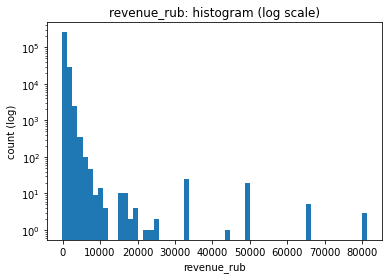

In [22]:
plt.figure() # строим гистограмму/ по вертикали делаем логарифмическую шкалу из-за большого разброса данных 
df["revenue_rub"].plot(kind="hist", bins=60, log=True)
plt.title("revenue_rub: histogram (log scale)")
plt.xlabel("revenue_rub")
plt.ylabel("count (log)")
plt.show()

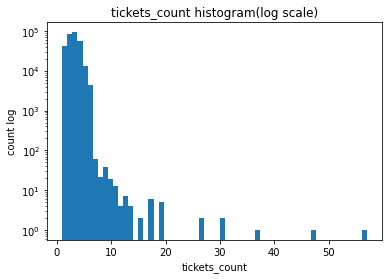

In [23]:
plt.figure() # строим гистограмму/ по вертикали делаем логарифмическую шкалу из-за большого разброса данных 
df["tickets_count"].plot(kind="hist", bins=60, log=True)
plt.title("tickets_count histogram(log scale)")
plt.xlabel("tickets_count")
plt.ylabel("count log")
plt.show()

In [24]:
p99 = df["revenue_rub"].quantile(0.99)
df = df[df["revenue_rub"] <= p99].copy() # отфильтровываем по 99-му процентилю

In [25]:
before = 290849  # объем отфильтрованных данных
after = len(df)

removed = before - after
removed_share = removed / before * 100

before, after, removed, removed_share

(290849, 288024, 2825, 0.9712943829959877)

Выполнена базовая проверка качества данных: изучены типы столбцов (df.info()), проверены пропуски (isna().sum(), список столбцов с NA). Пропуски обнаружены в days_since_prev — это ожидаемо, так как у части пользователей первая покупка.

Проведена оптимизация типов для снижения объёма памяти: даты приведены к корректным типам, числовые поля “ужаты”, а days_since_prev переведён в nullable-целочисленный тип (Int16).

Проверены распределения revenue_rub и tickets_count с помощью описательной статистики и графиков (гистограммы). В revenue_rub выявлены выбросы (значения существенно выше 99 перцентиля), поэтому выполнено отсечение по 99 перцентилю для дальнейшего анализа.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [26]:
df = df.sort_values(["user_id", "order_ts", "order_id"])# сортируем данные по времени совершения заказа. 

In [27]:
first= (df.groupby("user_id", as_index=False).first()[["user_id", "order_dt", "order_ts", "device_type_canonical",
                                                       "region_name", "service_name", "event_type_main",]]
       .rename(columns={"order_dt": "first_order_dt",
                      "order_ts": "first_order_ts",
                      "device_type_canonical": "first_device",
                      "region_name": "first_region",
                      "service_name": "first_service",
                      "event_type_main": "first_event_type"}))# находим первые заказы. 

In [28]:
agg= (df.groupby("user_id").agg(
                                last_order_dt=("order_dt", "max"),
                                orders_cnt=("order_id", "count"),
                                avg_revenue_rub=("revenue_rub", "mean"),
                                avg_tickets=("tickets_count", "mean"),
                                avg_days_between=("days_since_prev", "mean"),).reset_index())# находим нужные метрики. 

In [29]:
profile = first.merge(agg, on="user_id", how="left") # соединяем таблицы.

profile["is_two"] = (profile["orders_cnt"] >= 2).astype("int8")
profile["is_five"] = (profile["orders_cnt"] >= 5).astype("int8") # доьавдяем бинарные признаки.

profile.head()

,user_id,first_order_dt,first_order_ts,first_device,first_region,first_service,first_event_type,last_order_dt,orders_cnt,avg_revenue_rub,avg_tickets,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,2024-08-20,1,1521.940000,4.000000,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,mobile,Каменевский регион,Мой билет,выставки,2024-10-06,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-07-13 19:40:48,mobile,Североярская область,Лови билет!,другое,2024-10-23,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,2024-08-15,1,917.830000,4.000000,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,mobile,Поленовский край,Лучшие билеты,театр,2024-10-15,2,61.310000,1.500000,16.0,1,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [30]:
users_cnt = profile["user_id"].nunique()

avg_rev_per_order = round(profile["avg_revenue_rub"].mean(),2)

share_two = round(profile["is_two"].mean(),2)   
share_five = round(profile["is_five"].mean(),2)

users_cnt, avg_rev_per_order, share_two, share_five

(21861, 544.02, 0.62, 0.29)

In [31]:
profile[["orders_cnt","avg_tickets","avg_days_between"]].describe(
    percentiles=[.01,.05,.5,.95,.99]
).T # статистические показатели

,count,mean,std,min,1%,5%,50%,95%,99%,max
orders_cnt,21861.0,13.175244,121.739322,1.0,1.0,1.0,2.00,32.0,152.0,10188.0
avg_tickets,21861.0,2.742758,0.912988,1.0,1.0,1.0,2.75,4.0,5.0,11.0
avg_days_between,13523.0,15.845186,22.303361,0.0,0.0,0.0,8.00,61.5,112.0,148.0


In [32]:
p99_orders = profile["orders_cnt"].quantile(0.99)

before = len(profile)
profile_f = profile[profile["orders_cnt"] <= p99_orders].copy()
after = len(profile_f)

removed = before - after
removed_share = removed / before * 100

p99_orders, before, after, removed, removed_share

(152.0, 21861, 21644, 217, 0.9926352865834135)

В выборке 21861 пользователь, данных достаточно по объёму.
Распределение orders_cnt имеет длинный правый хвост: медиана 2, 99 перцентиль 152, максимум 10188 — аномальное значение.
avg_tickets в целом стабильный (99% = 5, max = 11) — похоже на редкие групповые заказы.
avg_days_between для пользователей с 2+ заказами (13523) имеет медиану 8 дней, присутствуют значения 0 (заказы в один день).
Для устранения влияния аномалий выполнено отсечение пользователей по orders_cnt на уровне 99 перцентиля; удалено 0.99% профилей.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [33]:
def segment_share(df, col):
    s = (df[col]
         .value_counts(dropna=False)
         .rename_axis(col)
         .reset_index(name="users_cnt"))
    s["share"] = (s["users_cnt"] / s["users_cnt"].sum()).round(4)
    return s # создаем функцию, которая будет считать показатели внутри каждого сегмента

In [34]:
seg_event = segment_share(profile, "first_event_type")
seg_device = segment_share(profile, "first_device")
seg_region = segment_share(profile, "first_region")
seg_service = segment_share(profile, "first_service")

seg_event.head(10), seg_device, seg_region.head(10), seg_service.head(10)# применяем функцию к нужным колонкам

(  first_event_type  users_cnt   share
 0         концерты       9637  0.4408
 1           другое       5483  0.2508
 2            театр       4285  0.1960
 3          стендап       1115  0.0510
 4            спорт        801  0.0366
 5         выставки        418  0.0191
 6             ёлки         95  0.0043
 7            фильм         27  0.0012,
   first_device  users_cnt   share
 0       mobile      18118  0.8288
 1      desktop       3743  0.1712,
            first_region  users_cnt   share
 0    Каменевский регион       7169  0.3279
 1  Североярская область       3801  0.1739
 2   Широковская область       1236  0.0565
 3      Озернинский край        678  0.0310
 4  Малиновоярский округ        528  0.0242
 5      Шанырский регион        503  0.0230
 6      Травяная область        493  0.0226
 7  Светополянский округ        464  0.0212
 8   Речиновская область        446  0.0204
 9   Яблоневская область        416  0.0190,
         first_service  users_cnt   share
 0  Билеты без 

1) По типу первого мероприятия
Концерты: 44.1% (9637) — главный входной сегмент.
Далее заметный “хвост”: другое 25.1%, театр 19.6%.
Топ-3 уже дают ~88.2% пользователей → сильная концентрация.

2) По устройству первой покупки
Mobile: 82.9% (18118)
Desktop: 17.1% (3743)
Очень сильная “точка входа” — мобильные.

3) По региону первого заказа
Каменевский регион: 32.8% (7169) — явный лидер.
Североярская область: 17.4% (3801) — второй крупный.
Дальше доли сильно меньше (≈2–6%). Значит пользователи географически сконцентрированы.

4) По билетному оператору первого заказа
Лидер: «Билеты без проблем» — 24.0% (5236)
Дальше: «Мой билет» 13.7%, «Лови билет!» 13.0%, «Билеты в руки» 11.9%, «Облачко» 10.0%
Тут концентрация умеренная: есть один лидер, но топ-5 операторов уже дают ~73.6%.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [35]:
overall_return = profile["is_two"].mean() # средняя доля возрата по всем пользователем 

In [36]:
def return_rate_by_segment(profile, seg_col, top_n=None):# Создаём функцию
    res = (profile
           .groupby(seg_col, dropna=False)# Группируем пользователей по значению seg_col
           .agg(users_cnt=("user_id", "nunique"),
                return_share=("is_two", "mean"))# Считаем две метрики для каждой группы
           .reset_index()#После groupby сегмент (seg_col) становится индексом.
                         # reset_index() возвращает его обратно обычной колонкой
           .sort_values("return_share", ascending=False))# сортируем по доле вернувшихся пользователей
    if top_n is not None:
        res = res.head(top_n) # на случай, если сегментов слишком много
    return res 

In [37]:
ret_event  = return_rate_by_segment(profile, "first_event_type")      #  сегментов мало
ret_device = return_rate_by_segment(profile, "first_device")          # 2 сегмента
ret_region = return_rate_by_segment(profile, "first_region", top_n=10)  # много сегментов. делаем топ-10
ret_serv   = return_rate_by_segment(profile, "first_service", top_n=10) # много сегментов. делаем топ-10
ret_event, ret_device, ret_region, ret_serv

(  first_event_type  users_cnt  return_share
 6            фильм         27      0.814815
 0         выставки        418      0.643541
 5            театр       4285      0.638273
 2         концерты       9637      0.621459
 4          стендап       1115      0.611659
 1           другое       5483      0.600766
 3            спорт        801      0.561798
 7             ёлки         95      0.557895,
   first_device  users_cnt  return_share
 0      desktop       3743      0.641197
 1       mobile      18118      0.612319,
               first_region  users_cnt  return_share
 5        Верхозёрский край          1      1.000000
 46  Озернопольская область         29      0.896552
 51    Радужнопольский край         23      0.782609
 36        Лесостепной край         61      0.721311
 12     Горноземский регион         29      0.689655
 11    Горицветская область        255      0.678431
 76        Шанырский регион        503      0.673956
 79    Ягодиновская область         64      0.

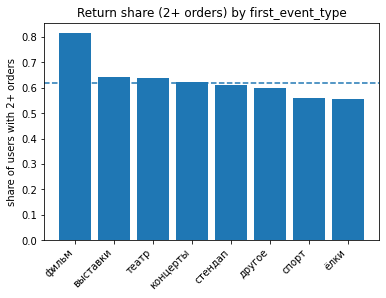

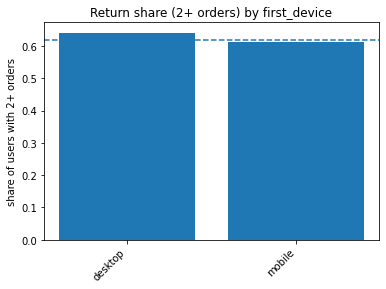

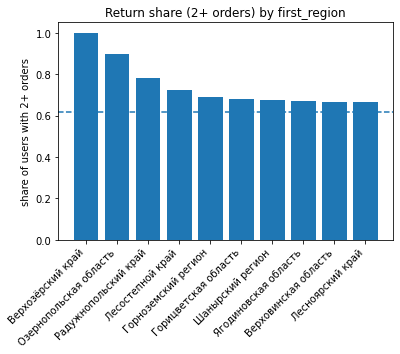

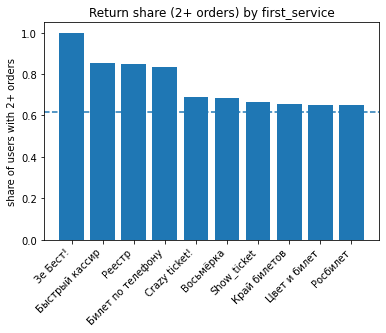

In [38]:
def plot_return(res, seg_col, overall):
    plt.figure()
    plt.bar(res[seg_col].astype(str), res["return_share"])
    plt.axhline(overall, linestyle="--")  # средняя доля возврата
    plt.title(f"Return share (2+ orders) by {seg_col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("share of users with 2+ orders")
    plt.show()

plot_return(ret_event,  "first_event_type", overall_return)
plot_return(ret_device, "first_device", overall_return)
plot_return(ret_region, "first_region", overall_return)
plot_return(ret_serv,   "first_service", overall_return)

Возвраты распределены неравномерно: среди крупных и поэтому надёжных сегментов чаще возвращаются пользователи, чей первый заказ был на театральные события, выставки и концерты (≈0.62–0.64), а также те, кто впервые покупал с desktop (0.64 против 0.61 у mobile). По регионам и операторам в топе встречаются сегменты с очень малым числом пользователей (единицы–десятки), их высокие доли возврата (0.8–1.0) нестабильны и не подходят для выводов; из более крупных сегментов выделяется оператор «Край билетов» (0.65 при 457 пользователях), что может указывать на успешную «точку входа».

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1 — не подтверждается: спорт (≈0.56) ниже концертов (≈0.62).Видно сразу по цифрам

In [39]:
#Гипотеза 2
TOP_N = 10

# 1) топ-10 регионов по числу пользователей
top_regions = (profile["first_region"]
               .value_counts()
               .head(TOP_N)
               .index)

# 2) помечаем группы: топ-10 vs остальные
profile["region_group"] = profile["first_region"].where(profile["first_region"].isin(top_regions), "others")

# 3) сравниваем долю возвратов
h2 = (profile.groupby("region_group")
      .agg(users_cnt=("user_id", "nunique"),
           return_share=("is_two", "mean"))
      .reset_index()
      .sort_values("users_cnt", ascending=False))

h2

,region_group,users_cnt,return_share
1,Каменевский регион,7169,0.628261
0,others,6127,0.586258
6,Североярская область,3801,0.640884
9,Широковская область,1236,0.650485
3,Озернинский край,678,0.554572
2,Малиновоярский округ,528,0.562500
8,Шанырский регион,503,0.673956
7,Травяная область,493,0.618661
5,Светополянский округ,464,0.661638
4,Речиновская область,446,0.639013


В целом гипотеза подтверждается.В регионах с наибольшим числом пользователей доля повторных заказов чаще выше, чем в группе “остальные” (0.586), но не во всех топ-регионах — есть регионы-исключения с более низкой долей возврата.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


In [40]:
one = profile[profile["orders_cnt"] == 1]["avg_revenue_rub"].dropna()
ret = profile[profile["orders_cnt"] >= 2]["avg_revenue_rub"].dropna()

NameError: name 'bins' is not defined

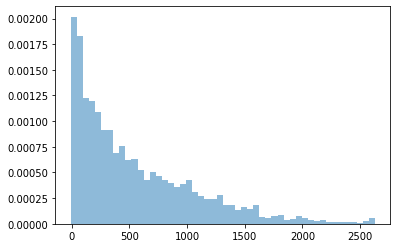

In [41]:
plt.figure()
plt.hist(one, bins=50, density=True, alpha=0.5, label="1 order")
plt.hist(ret, bins=bins, density=True, alpha=0.5, label="2+ orders")
plt.title("avg_revenue_rub distribution: 1 order vs 2+ orders")
plt.xlabel("avg_revenue_rub")
plt.ylabel("density")
plt.legend()
plt.show()

Пользователи с 1 заказом сильнее всего концентрируются на очень низкой средней выручке — пик примерно в диапазоне 0–200 ₽, дальше распределение плавно убывает с длинным хвостом.
Вернувшиеся (2+ заказов) распределены правее: основной пик примерно 300–700 ₽, и в целом доля пользователей с более высокой средней выручкой у них выше.

Различия между группами есть: у вернувшихся пользователей распределение avg_revenue_rub заметно смещено вправо, то есть они в среднем делают более “дорогие” заказы, чем пользователи с одним заказом. Это поддерживает идею, что более крупные/дорогие покупки связаны с большей вероятностью возврата.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


In [ ]:
g_2_4 = profile[(profile["orders_cnt"] >= 2) & (profile["orders_cnt"] <= 4)]["avg_revenue_rub"].dropna()
g_5p  = profile[profile["orders_cnt"] >= 5]["avg_revenue_rub"].dropna()

bins = 50

plt.figure()
plt.hist(g_2_4, bins=bins, density=True, alpha=0.5, label="2–4 orders")
plt.hist(g_5p,  bins=bins, density=True, alpha=0.5, label="5+ orders")
plt.title("avg_revenue_rub: 2–4 orders vs 5+ orders")
plt.xlabel("avg_revenue_rub")
plt.ylabel("density")
plt.legend()
plt.show()

Различия между группами очевидны. Пользователи с 5+ заказами в среднем делают более дорогие заказы, чем пользователи с 2–4 заказами; это может быть признаком большей вовлечённости.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

In [ ]:
profile["avg_tickets"].describe(percentiles=[.01,.05,.5,.95,.99])

In [ ]:
bins = [1, 2, 3, 5, float("inf")]
labels = ["1–2", "2–3", "3–5", "5+"]

profile["tickets_segment"] = pd.cut(
    profile["avg_tickets"],
    bins=bins,
    labels=labels,
    right=False,          
    include_lowest=True
)

profile["tickets_segment"].value_counts(dropna=False)

Распределение avg_tickets достаточно компактное и смещено к небольшим значениям: среднее — 2.74 билета, медиана — 2.75, при этом минимум 1, а максимум 11. Основная масса пользователей сосредоточена в диапазоне 2–5 билетов: сегменты 2–3 (9709 пользователей) и 3–5 (9069) покрывают подавляющую часть выборки; заметно меньше пользователей покупают в среднем 1–2 билета (2422), и совсем небольшая доля относится к 5+ (661). По перцентилям видно, что у 95% пользователей среднее число билетов не превышает 4, а у 99% — 5, то есть значения выше 5 встречаются редко и формируют “хвост” распределения.

In [ ]:
seg = (profile.groupby("tickets_segment")
       .agg(users_cnt=("user_id", "nunique"),
            return_share=("is_two", "mean"))
       .reset_index())

seg["return_share"] = seg["return_share"].round(4)
seg

Пользователи распределены сконцентрировано: почти все находятся в сегментах 2–3 (9709) и 3–5 (9069), тогда как 1–2 (2422) заметно меньше, а 5+ (661) — самый маленький сегмент. По доле повторных покупок есть явные “аномалии”: сегмент 2–3 билета имеет очень высокую долю возврата (0.7417) по сравнению с остальными, а сегмент 5+ билетов — аномально низкую (0.1876); при этом для 5+ нужно учитывать небольшой размер сегмента, но разница всё равно выглядит существенно.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [43]:
# день недели (0=Mon ... 6=Sun)
profile["first_order_dt"] = pd.to_datetime(profile["first_order_dt"], errors="coerce")
profile["first_weekday"] = profile["first_order_dt"].dt.dayofweek

# подписи дней
weekday_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
profile["first_weekday_name"] = profile["first_weekday"].map(weekday_map)

In [45]:
by_wd = (profile.groupby("first_weekday_name")
         .agg(users_cnt=("user_id", "nunique"),
              return_share=("is_two", "mean"))
         .reset_index())

# определим последовательгость дней, чтобы дни шли по порядку
order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
by_wd["first_weekday_name"] = pd.Categorical(by_wd["first_weekday_name"], categories=order, ordered=True)
by_wd = by_wd.sort_values("first_weekday_name")

by_wd

,first_weekday_name,users_cnt,return_share
1,Mon,2945,0.632258
5,Tue,3191,0.620495
6,Wed,3074,0.623617
4,Thu,3118,0.595253
0,Fri,3259,0.599264
2,Sat,3460,0.642775
3,Sun,2814,0.604833


Пользователи по дням недели распределены довольно равномерно (≈2.8–3.5 тыс. на день), чуть больше первых покупок приходится на субботу и пятницу. Доля повторных заказов отличается умеренно: выше всего у пользователей, сделавших первый заказ в субботу (0.643) и понедельник (0.632), ниже — в четверг (0.595) и пятницу (0.599); разница между максимумом и минимумом около 5 п.п., поэтому влияние дня недели заметно, но не сильное.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [48]:
g_2_4 = profile[(profile["orders_cnt"] >= 2) & (profile["orders_cnt"] <= 4)]["avg_days_between"].dropna()
g_5p  = profile[profile["orders_cnt"] >= 5]["avg_days_between"].dropna()

g_2_4.mean().round(2), g_5p.mean().round(2) # Средний интервал между заказами для групп 2–4 и 5+

(21.32, 9.59)

In [50]:
g_2_4.median(), g_5p.median().round(1) # с медианой

(9.0, 7.8)

Вывод:чем меньше средний интервал между заказами, тем выше вероятность повторных заказов и тем больше вероятность перейти в группу частых покупателей (5+).

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [55]:
profile = profile.copy()# Подготовим датафрейм
profile = profile.rename(columns={"orders_cnt": "total_orders"})

# какие признаки профиля берём
cols = [
    "total_orders",
    "avg_revenue_rub",
    "avg_tickets",
    "avg_days_between",
    "first_device",
    "first_region",
    "first_service",
    "first_event_type",
    "first_weekday_name",  
]

df_corr = profile[cols].copy()


In [56]:
interval_cols = ["total_orders", "avg_revenue_rub", "avg_tickets", "avg_days_between"]# Укажем интервальные колонки

In [57]:
phik_all = df_corr.phik_matrix(interval_cols=interval_cols)

# сортируем признаки по силе связи с total_orders
phik_vs_orders = phik_all["total_orders"].sort_values(ascending=False)
phik_vs_orders

total_orders          1.000000
first_region          0.127225
first_service         0.101933
first_weekday_name    0.055519
avg_revenue_rub       0.000000
avg_tickets           0.000000
avg_days_between      0.000000
first_device          0.000000
first_event_type      0.000000
Name: total_orders, dtype: float64

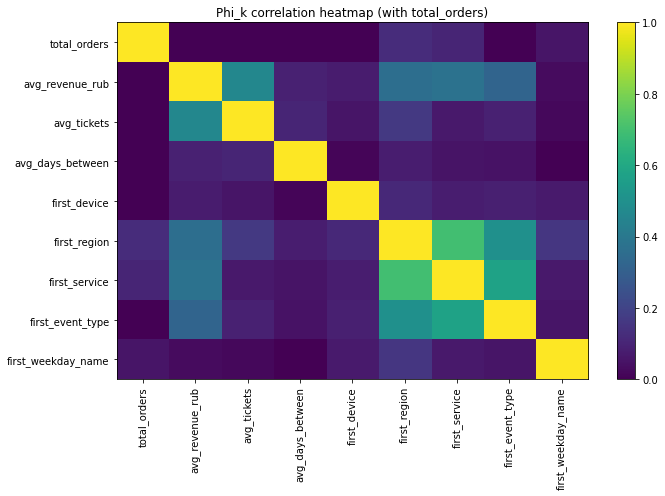

In [58]:
plt.figure(figsize=(10, 7))
plt.imshow(phik_all, aspect="auto")
plt.colorbar()
plt.xticks(range(len(phik_all.columns)), phik_all.columns, rotation=90)
plt.yticks(range(len(phik_all.index)), phik_all.index)
plt.title("Phi_k correlation heatmap (with total_orders)")
plt.tight_layout()
plt.show()

Корреляционный анализ phi_k показал, что число заказов (total_orders) почти не связано с большинством признаков профиля: для avg_revenue_rub, avg_tickets, avg_days_between, first_device и first_event_type связь близка к нулю. Небольшая, но заметная связь наблюдается только у признаков, связанных с «точкой входа» по географии и партнёру: first_region (phi_k ≈ 0.13) и first_service (phi_k ≈ 0.10); влияние дня недели первого заказа слабое (≈ 0.06).

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

Данные и подготовка. В работе использованы данные заказов Яндекс Афиши за лето и первые два месяца осени 2024 года (таблица покупок + справочники мероприятий и географии). Данные ограничены покупками с устройств mobile/desktop, из анализа исключены фильмы. Рассчитаны поведенческие признаки: days_since_prev (дни между заказами). Выручка приведена к единой валюте: для оплат в KZT использован курс руб/100 KZT, получен столбец revenue_rub. Проведена проверка пропусков и типов, оптимизированы числовые типы. Для revenue_rub выявлены выбросы (max значительно выше 99-го перцентиля), поэтому выполнено отсечение по 99 перцентилю для устойчивого анализа.

В выборке 21 861 пользователь. Распределение заказов по пользователям имеет длинный хвост: медиана — 2 заказа, при этом есть экстремальные выбросы (до 10k заказов), которые требуют фильтрации при анализе. Возвраты (2+ заказа) заметно зависят от «точки входа»: по типу первого события стабильно выше доля повторных покупок у театра/выставок/концертов (в пределах ~0.62–0.64 для крупных сегментов), а по устройству сильнее возвращаются пользователи, начавшие с desktop (≈0.64 против ≈0.61 у mobile). По регионам гипотеза “в более активных регионах выше возврат” подтверждается частично: у большинства крупнейших регионов доля возврата выше, чем у группы “others”, но есть регионы-исключения с более низким возвратом. По среднему чеку видно различие: распределение avg_revenue_rub у вернувшихся пользователей смещено вправо, а у пользователей с 5+ заказами средняя выручка с заказа выше, чем у пользователей с 2–4 заказами. По билетам картина неоднозначная: основной массив пользователей в диапазоне 2–5 билетов, при этом сегмент 2–3 билета показал высокую долю возврата, а сегмент 5+ — низкую (при сравнительно небольшом размере сегмента). Среди временных факторов день недели первого заказа влияет умеренно (разброс долей возврата около нескольких п.п.), а ключевой фактор удержания — интервал между покупками: у пользователей с 5+ заказами средний интервал существенно меньше (≈9.6 дня) по сравнению с группой 2–4 (≈21.3 дня), что указывает на связь “чем быстрее повторная покупка — тем выше долгосрочное удержание”. Корреляционный анализ phi_k с числом заказов показал слабые связи почти со всеми признаками, кроме небольшого влияния первого региона и первого партнёра; это означает, что “точки входа” важнее для удержания, чем средний чек сам по себе в рамках корреляции с total_orders.

Рекомендации заказчику.

Усилить успешные точки входа: концерты/театр/выставки и desktop-канал показывают более высокий возврат — имеет смысл поддержать эти сегменты в performance-маркетинге и персонализации первого опыта.
Работать с “быстрым повтором”: так как короткий интервал между покупками связан с большим числом заказов, целесообразны триггеры на 3–14 дней после первой покупки (подборки похожих событий, персональные рекомендации, мягкие скидки/пуши).
Проверить сегмент 5+ билетов: очень низкий возврат может означать разовые групповые покупки (корпоративы/семьи). Для них стоит тестировать отдельные коммуникации (групповые предложения, “повтори с друзьями”, семейные подборки), но учитывать, что сегмент меньше по объёму.
Региональная стратегия: в топ-регионах возврат чаще выше, но есть исключения — их стоит отдельно диагностировать (качество ассортимента, партнёры, доступность мероприятий) и запустить локальные эксперименты.
Контроль качества данных: аномалии по выручке (отрицательные/нулевые значения) и экстремальные “суперактивные” пользователи требуют регулярного мониторинга и фильтрации перед продуктовой аналитикой.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**